In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [27]:
df=pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


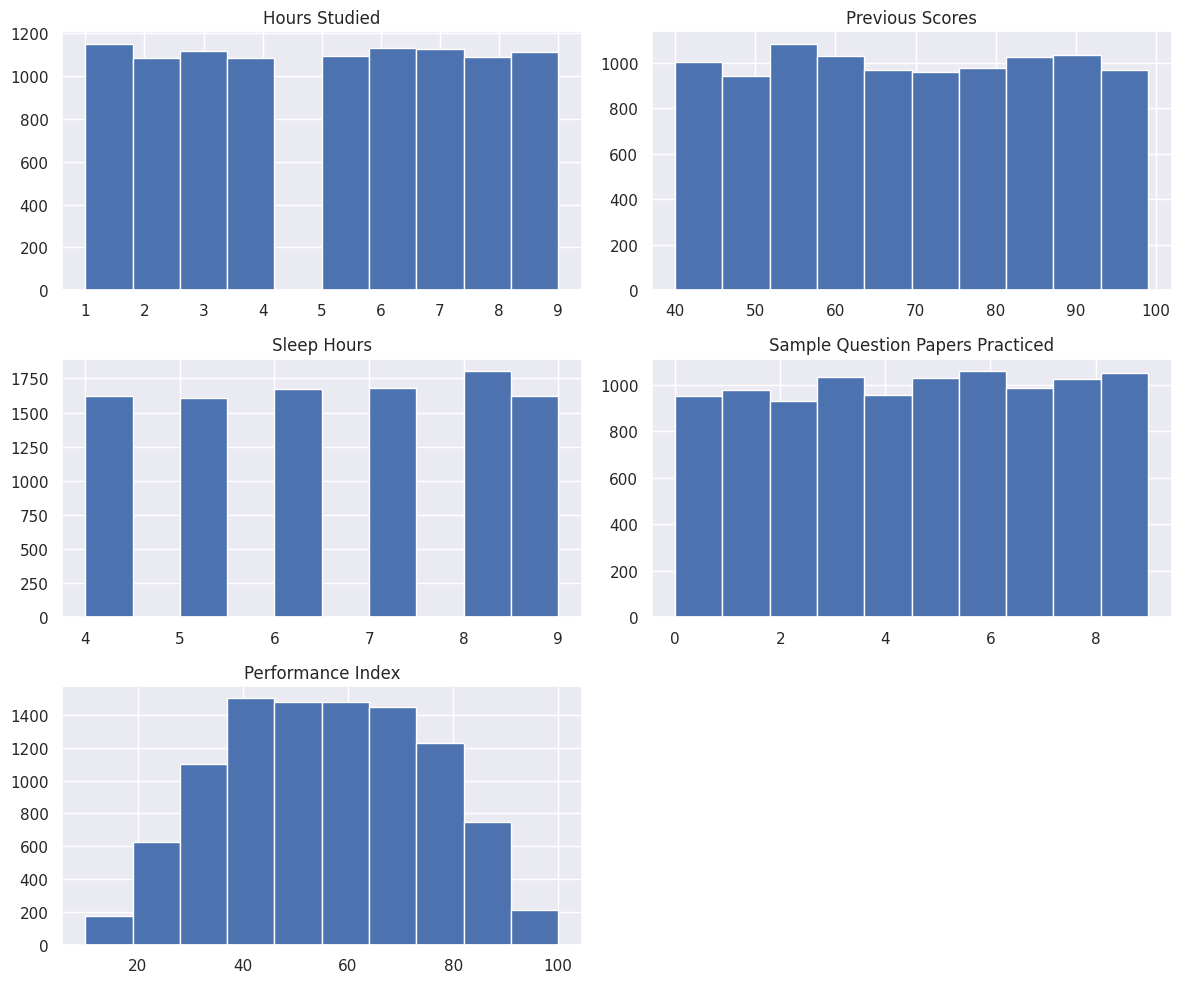

In [28]:

# Create histograms with custom figure size and spacing
ax = df.hist(figsize=(12, 10))   # adjust width x height
plt.tight_layout()               # automatically adjust spacing
plt.show()

<Axes: xlabel='Extracurricular Activities', ylabel='Performance Index'>

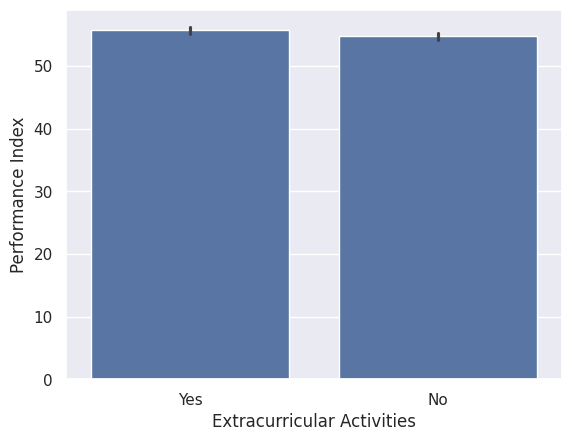

In [29]:
import seaborn as sns
sns.set()
sns.barplot(data =df , x = 'Extracurricular Activities' , y = 'Performance Index')

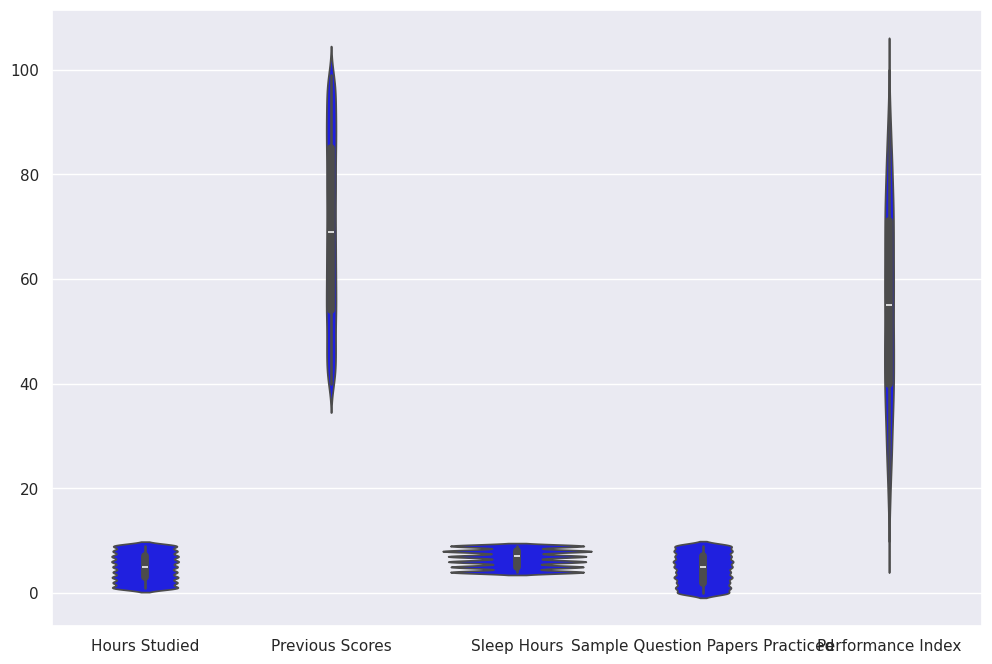

In [30]:

# Set figure size before plotting
plt.figure(figsize=(12, 8))   # width=12, height=8 in inches
sns.violinplot(data=df, color='blue')

plt.show()

In [31]:
X = df.drop('Performance Index',axis=1)
y = df['Performance Index']

In [32]:
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,Yes,9,1
1,4,82,No,4,2
2,8,51,Yes,7,2
3,5,52,Yes,5,2
4,7,75,No,8,5


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = ['Extracurricular Activities']
numerical_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# Create a ColumnTransformer to apply OneHotEncoder to categorical features and StandardScaler to numerical features
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), categorical_features),
                                     ('scaler', StandardScaler(), numerical_features)],
                       remainder='passthrough')

# Apply the ColumnTransformer to the features
X = ct.fit_transform(X)

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: >]], dtype=object)

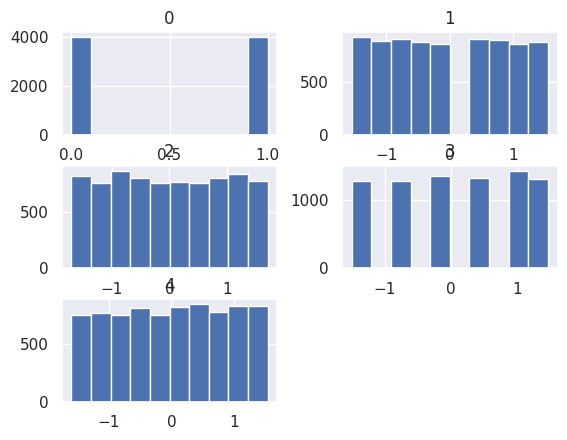

In [35]:
X_train = pd.DataFrame(X_train)
X_train.hist()

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: >]], dtype=object)

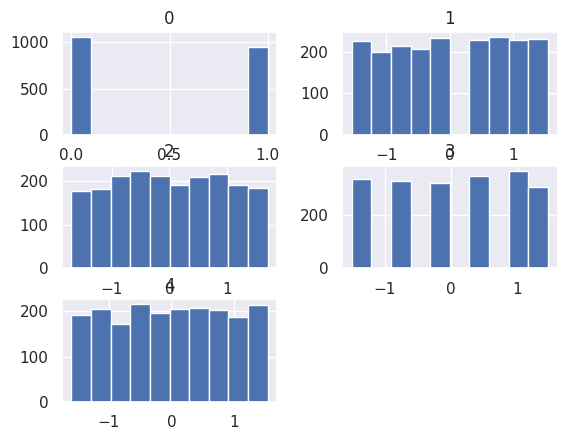

In [36]:
x_test = pd.DataFrame(X_test)
x_test.hist()

In [37]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 5), (2000, 5), (8000,), (2000,))

In [38]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = regressor.predict(X_test).round(1)

In [40]:
calculation = pd.DataFrame(np.c_[y_test,y_pred], columns = ["Original Salary","Predict Salary"])
calculation.head(5)

,Original Salary,Predict Salary
0,53.0,50.5
1,50.0,53.1
2,80.0,78.2
3,24.0,25.4
4,64.0,67.4


In [41]:
print("Training Accuracy :", regressor.score(X_train, y_train))
print("Testing Accuracy :", regressor.score(X_test, y_test))

Training Accuracy : 0.9889033042773491
Testing Accuracy : 0.9880686410711422


In [42]:
new_data = pd.DataFrame([[7, 90, 8, 3, 'Yes']], columns=['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities'])

# Apply the same ColumnTransformer used for training data
scaled_new_data = ct.transform(new_data)

# Predict using the trained regressor
predicted_performance = regressor.predict(scaled_new_data)

print("Predicted Performance Index:", predicted_performance[0].round(1))

Predicted Performance Index: 82.6


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Separate features and target
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessing: scale numeric, encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Build pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train
model.fit(X, y)

# Predict
y_pred = model.predict(X)
print(y_pred[:10])

[91.85200884 63.15778719 45.05283229 36.55120081 67.09133945 59.4090757
 64.41949152 38.27575643 62.8408373  69.89922226]


/tmp/ipykernel_19742/3639719859.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns
